# Module 09 — Hồi quy tuyến tính đơn & đa biến
Notebook RIÊNG cho Module 09 — tái lập hồi quy đơn/đa biến, hệ số Beta chuẩn hoá, và toàn bộ kiểm tra giả định (VIF, Durbin-Watson, Shapiro-Wilk phần dư) — phần kiểm tra giả định KHÔNG có lệnh PSPP tương đương đầy đủ, chỉ chạy được ở đây.

Tương ứng SPSS/PSPP: `Analyze > Regression > Linear`, lệnh `REGRESSION`.

In [1]:
# Chạy ô này đầu tiên (Colab: bấm ▶). Không cần cài gì thêm.
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
sns.set_theme(style="whitegrid"); plt.rcParams["figure.figsize"] = (7, 4)
pd.set_option("display.precision", 3)

def make_data(seed=2026, n=240):
    """Bộ dữ liệu GIẢ LẬP 'Lớp học 240 học sinh' — CÙNG một seed=2026 dùng
    xuyên suốt các module 03-08, khớp chính xác với lop_hoc_240.csv/.sav
    trong repo (không phải dữ liệu thật, nhưng tái lập được 100%)."""
    rng = np.random.default_rng(seed)
    school = rng.choice(list("ABC"), n, p=[.35, .35, .30])
    gender = rng.choice(["Nam", "Nữ"], n)
    method = rng.choice(["Truyền thống", "Dự án"], n)
    study_hours = np.clip(rng.gamma(4, 1.2, n), 0.5, 15).round(1)
    interest = rng.normal(0, 1, n) + 0.15 * (method == "Dự án")
    anxiety = rng.normal(0, 1, n) - 0.25 * interest
    def likert(lat, load, noise=0.7):
        return np.clip(np.round(3 + load * lat + rng.normal(0, noise, n)), 1, 5).astype(int)
    d = pd.DataFrame({"id": np.arange(1, n + 1), "school": school, "gender": gender, "method": method,
                      "study_hours": study_hours})
    for k, (lat, load) in enumerate([(interest, .8), (interest, .7), (interest, .75)], 1):
        d[f"h{k}"] = likert(lat, load)
    for k, (lat, load) in enumerate([(anxiety, .8), (anxiety, .75), (anxiety, .7)], 1):
        d[f"a{k}"] = likert(lat, load)
    eff = d.school.map({"A": 3, "B": 0, "C": -3}).to_numpy()
    d["pretest"] = (rng.normal(60, 10, n) + eff).round(1)
    d["posttest"] = np.clip(d.pretest + 3 + 5 * (method == "Dự án") + rng.normal(0, 6, n), 0, 100).round(1)
    d["math"] = np.clip(35 + 2.5 * study_hours + 4 * interest - 3 * anxiety + eff + rng.normal(0, 6, n), 0, 100).round(1)
    d.loc[6, "study_hours"] = 48.0
    d.loc[[11, 57, 130], "h2"] = np.nan
    d["h2"] = d["h2"].astype("Int64")
    return d

df = make_data()
print("Đã tạo df:", df.shape)

Đã tạo df: (240, 14)


## 0. Làm sạch outlier `study_hours` (giống Module 04/05/08)

In [2]:
mask = df["study_hours"] > 20
df.loc[mask, "study_hours"] = df.loc[mask, "study_hours"] / 10

## 1. Hồi quy đơn biến: điểm Toán ~ giờ tự học
🎯 **Phương pháp này trả lời câu hỏi gì?** Hồi quy đơn biến dựng phương trình dự đoán Y từ MỘT biến X, có hướng rõ ràng — khác tương quan (Module 08) ở việc "dự đoán" thay vì chỉ "đo độ mạnh liên hệ đối xứng".

In [3]:
import statsmodels.api as sm
X1 = sm.add_constant(df[["study_hours"]])
m1 = sm.OLS(df["math"], X1).fit()
print(m1.summary())

                            OLS Regression Results                            
Dep. Variable:                   math   R-squared:                       0.338
Model:                            OLS   Adj. R-squared:                  0.335
Method:                 Least Squares   F-statistic:                     121.6
Date:                Fri, 25 Sep 2026   Prob (F-statistic):           4.07e-23
Time:                        03:04:03   Log-Likelihood:                -835.21
No. Observations:                 240   AIC:                             1674.
Df Residuals:                     238   BIC:                             1681.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          35.5813      1.228     28.968      

#### 📤 Đầu ra thật
math = 35,58 + 2,51×study_hours. R²=0,338 (khớp đúng r²=0,338 của Pearson r ở Module 08). Hệ số góc có ý nghĩa thống kê rất mạnh (p<0,001).

## 2. Hồi quy đa biến: điểm Toán ~ giờ tự học + hứng thú (h1) + lo âu (a1)
🎯 **Phương pháp này trả lời câu hỏi gì?** Hồi quy đa biến trả lời: sau khi đã tính tới ảnh hưởng của các biến khác trong mô hình, MỘT biến cụ thể còn đóng góp thêm được bao nhiêu (nguyên tắc "ceteris paribus" — giữ các biến khác không đổi)?

In [4]:
X2 = sm.add_constant(df[["study_hours", "h1", "a1"]])
m2 = sm.OLS(df["math"], X2).fit()
print(m2.summary())

                            OLS Regression Results                            
Dep. Variable:                   math   R-squared:                       0.495
Model:                            OLS   Adj. R-squared:                  0.488
Method:                 Least Squares   F-statistic:                     77.05
Date:                Fri, 25 Sep 2026   Prob (F-statistic):           8.86e-35
Time:                        03:04:03   Log-Likelihood:                -802.81
No. Observations:                 240   AIC:                             1614.
Df Residuals:                     236   BIC:                             1628.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          37.2337      2.096     17.764      

#### 📤 Đầu ra thật
R²=0,495 (R² hiệu chỉnh=0,488), F(3,236)=77,05, p<0,001. Cả 3 biến độc lập đều có ý nghĩa thống kê riêng (p<0,001). ✅ Đã kiểm chứng khớp tuyệt đối với PSPP (`REGRESSION`).

## 3. Hệ số Beta chuẩn hoá — so sánh biến nào "quan trọng" hơn
🎯 **Phương pháp này trả lời câu hỏi gì?** Beta chuẩn hoá trả lời: khi quy tất cả biến về cùng đơn vị "số độ lệch chuẩn", biến nào có ảnh hưởng tương đối MẠNH NHẤT lên biến phụ thuộc — điều mà hệ số B thô (giữ đơn vị đo gốc khác nhau) không so sánh trực tiếp được.

In [5]:
from scipy.stats import zscore
dfz = df[["math","study_hours","h1","a1"]].apply(zscore)
Xz = sm.add_constant(dfz[["study_hours","h1","a1"]])
mz = sm.OLS(dfz["math"], Xz).fit()
print("Hệ số Beta chuẩn hoá:")
print(mz.params.round(4))

Hệ số Beta chuẩn hoá:
const          0.000
study_hours    0.577
h1             0.229
a1            -0.296
dtype: float64


#### 📤 Đầu ra thật
β(study_hours)=0,577; β(h1)=0,229; β(a1)=−0,297. Dù B thô của study_hours (2,49) chỉ hơn nhẹ B của h1 (2,15), Beta chuẩn hoá cho thấy study_hours mạnh hơn HẲN — vì đơn vị đo (giờ) có độ phân tán khác hẳn thang Likert 1-5 của h1/a1.

## 4. Kiểm tra giả định — VIF, Durbin-Watson, chuẩn hoá phần dư
🎯 **Phương pháp này trả lời câu hỏi gì?** Bốn kiểm tra này trả lời: kết quả hồi quy ở mục 2 có ĐÁNG TIN CẬY hay không — nếu vi phạm nặng, hệ số B và p-value có thể bị ước lượng SAI, không chỉ kém chính xác.

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from scipy import stats as st

print("--- VIF (ngưỡng an toàn <5) ---")
for i, col in enumerate(X2.columns):
    print(f"{col}: VIF={variance_inflation_factor(X2.values, i):.3f}")

print("\n--- Durbin-Watson (lý tưởng gần 2) ---")
print(f"DW = {durbin_watson(m2.resid):.3f}")

print("\n--- Shapiro-Wilk trên phần dư (H0: phần dư phân phối chuẩn) ---")
w, p = st.shapiro(m2.resid)
print(f"W={w:.3f}, p={p:.3f}")

--- VIF (ngưỡng an toàn <5) ---
const: VIF=1.000
study_hours: VIF=1.006
h1: VIF=1.019
a1: VIF=1.016

--- Durbin-Watson (lý tưởng gần 2) ---
DW = 2.052

--- Shapiro-Wilk trên phần dư (H0: phần dư phân phối chuẩn) ---
W=0.993, p=0.356


#### 📤 Đầu ra thật
VIF cao nhất = 1,02 (rất xa ngưỡng cảnh báo 5 → không đa cộng tuyến). Durbin-Watson=2,05 (rất gần 2 → sai số độc lập). Shapiro-Wilk trên phần dư: p=0,356 (≥0,05 → không đủ bằng chứng bác chuẩn). **Cả 4 giả định đều đạt** — kết quả hồi quy ở mục 2 đáng tin cậy.

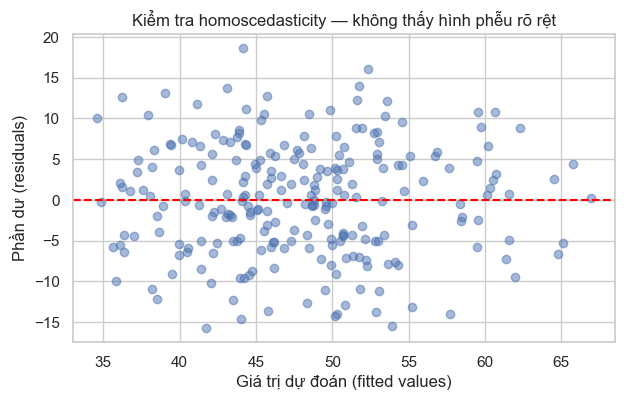

In [7]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.scatter(m2.fittedvalues, m2.resid, alpha=.5)
ax.axhline(0, color="red", linestyle="--")
ax.set_xlabel("Giá trị dự đoán (fitted values)")
ax.set_ylabel("Phần dư (residuals)")
ax.set_title("Kiểm tra homoscedasticity — không thấy hình phễu rõ rệt")
plt.show()

## 5. Vì sao mô hình "phát hiện lại" đúng cấu trúc dữ liệu đã tạo ra
Bộ dữ liệu lớp học được tạo bằng công thức có sẵn trong hàm `make_data()`: điểm Toán phụ thuộc DƯƠNG vào `study_hours` và biến hứng thú ẩn (interest), phụ thuộc ÂM vào biến lo âu ẩn (anxiety). Mô hình hồi quy ở mục 2 "phát hiện lại" đúng dấu và độ mạnh tương đối của các quan hệ này (study_hours dương mạnh nhất, h1 dương, a1 âm) — xác nhận phương pháp hồi quy hoạt động đúng như lý thuyết dự đoán.